In [1]:
import os
import sys
src_dir = "../../src"
if src_dir not in sys.path:
    sys.path.append(src_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from utils.error_report import get_error_from_list
from utils import lla_to_enu, ecef_to_lla, get_rigid_transformation
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm


%matplotlib inline
np.random.seed(777)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


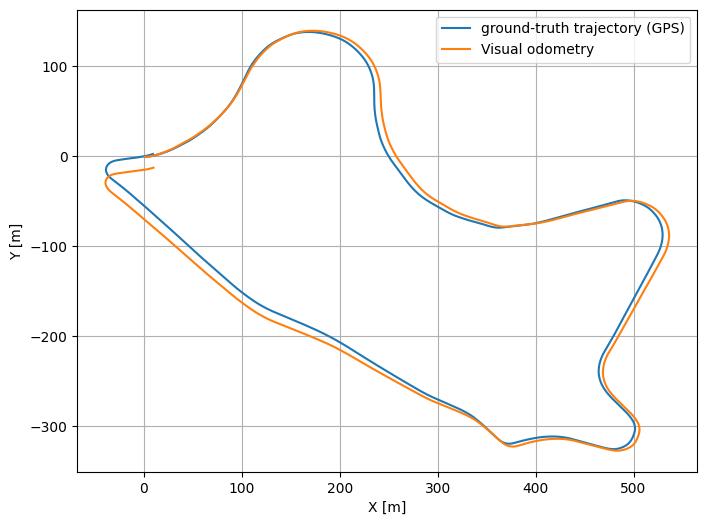

In [2]:
root_path = "../../"

file_export_path = os.path.join(root_path, "exports/particle_filter")
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")

pose_dir = os.path.join(kitti_root_dir, "poses")
calib_dir = os.path.join(kitti_root_dir, "sequences", "09")

kitti_dataset = "0033"

data = DataLoader(sequence_nr=kitti_dataset, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

In [64]:
# calculating norm of displacement frame by frame.
temp = np.linalg.norm(np.diff(data.GPS_measurements_in_meter, axis=0), axis=1)
# calculating velocity from the formula, v = s / dt.
temp = temp / np.diff(np.array(data.ts))
# inserting the first row of the velocity vector.
temp = np.vstack([temp[0].reshape(-1, 1), temp.reshape(-1, 1)]).reshape(-1)

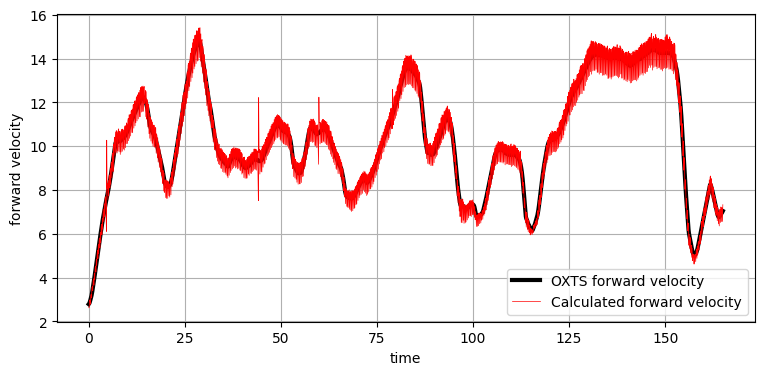

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.plot(data.ts, data.INS_velocities[:, 0], label="OXTS forward velocity", color="black", lw=3)
ax.plot(data.ts, temp, label="Calculated forward velocity", color="red", lw=0.5)
ax.set_xlabel('time')
ax.set_ylabel('forward velocity')
ax.legend()
ax.grid()

### Conclusion

This proves that the forward velocity of oxts is obtained from the displacement of gps value divided by the delta time.
Since the oxts forward velocity is smoothed, presumably Kalman filter is applied to obtain the estimated velocity.